# DX799 Week 6: Decision Trees and Random Forests

This notebook applies decision trees and random forests to the diabetes health indicators dataset from the BRFSS 2015 survey. We continue using the top predictive features identified in Weeks 1-5 (GenHlth, BMI, HighBP, Age, HighChol) and compare these models against the linear and SVM approaches from prior weeks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Load Data

Load the same BRFSS 2015 diabetes dataset used in Weeks 1-5.

In [2]:
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## Feature Selection and Train/Test Split

Five features used: GenHlth, BMI, HighBP, Age, HighChol, consistent with Weeks 1-5. Decision trees and random forests do not require feature scaling, since splits are based on threshold values rather than distances. Same 80/20 train/test split as prior weeks.

In [3]:
features = ['GenHlth', 'BMI', 'HighBP', 'Age', 'HighChol']
X = df[features]
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (56553, 5)
Test set: (14139, 5)


## Decision Tree Classifier

Default decision tree with no depth restriction, to first observe baseline behavior before applying overfitting controls.

In [4]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

print(f"Decision Tree (default, no max depth)")
print(f"Accuracy: {acc_dt:.4f}")
print(f"AUC-ROC: {auc_dt:.4f}")
print(f"Tree depth: {dt.get_depth()}")

Decision Tree (default, no max depth)
Accuracy: 0.7203
AUC-ROC: 0.7817
Tree depth: 24


## Controlling Overfitting with Max Depth

The unrestricted tree reached depth 24, indicating overfitting to training data noise. Max depth is tested across several values to find the point that balances fit and generalization.

In [5]:
depths = [2, 3, 4, 5, 6, 10, 15]
results = []

for depth in depths:
    dt_d = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_d.fit(X_train, y_train)
    y_pred_d = dt_d.predict(X_test)
    acc_d = accuracy_score(y_test, y_pred_d)
    auc_d = roc_auc_score(y_test, dt_d.predict_proba(X_test)[:, 1])
    results.append({'Max Depth': depth, 'Accuracy': acc_d, 'AUC-ROC': auc_d})

results_df = pd.DataFrame(results)
print(results_df)

   Max Depth  Accuracy   AUC-ROC
0          2  0.699696  0.751035
1          3  0.716246  0.780345
2          4  0.727986  0.796191
3          5  0.735201  0.808078
4          6  0.736120  0.813470
5         10  0.735271  0.808480
6         15  0.721904  0.784737


## Visualizing the Decision Tree

The tree at max depth 6, the best-performing depth identified above, is plotted to show the actual split structure and decision logic.

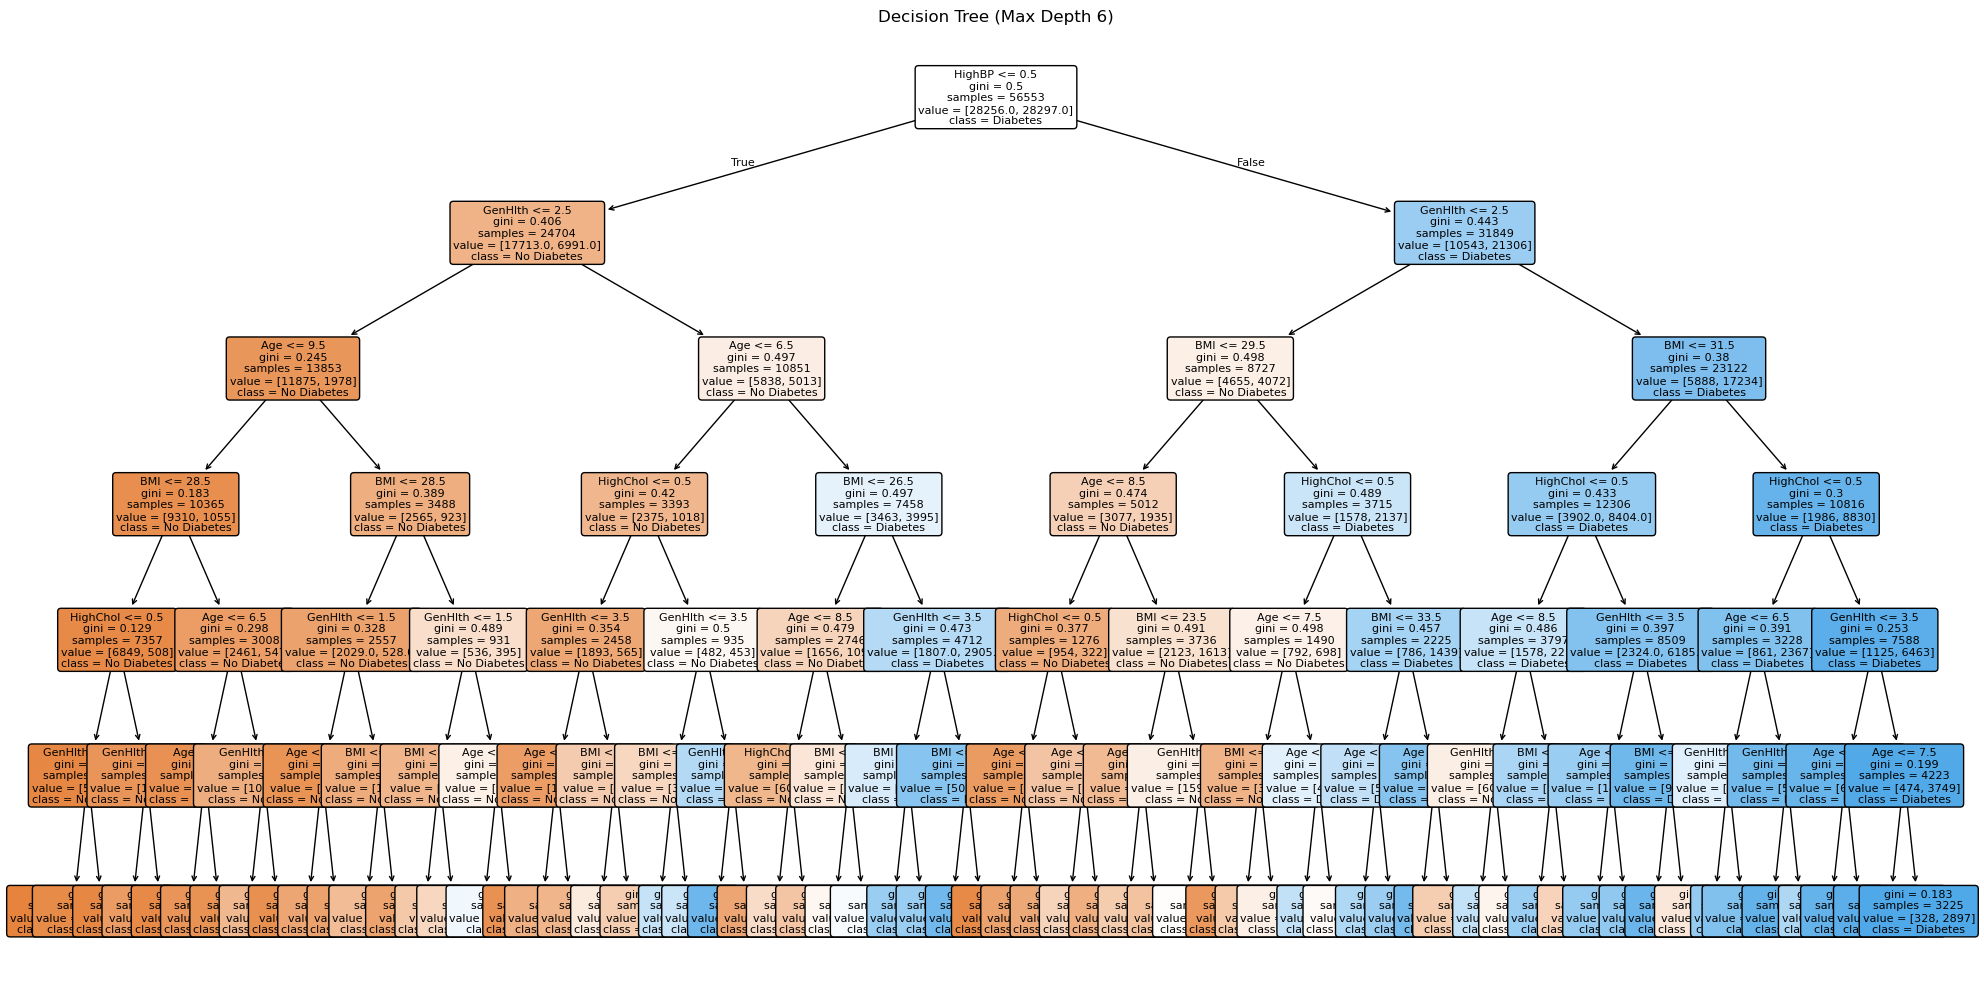

In [6]:
dt_best = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_best.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_best, feature_names=features, class_names=['No Diabetes', 'Diabetes'],
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (Max Depth 6)')
plt.tight_layout()
plt.show()

## Simplified Tree for Visualization

A depth 3 tree is shown purely for visual clarity. Performance results above used depth 6 as the optimal depth; this shallower version illustrates the splitting logic in a readable format.

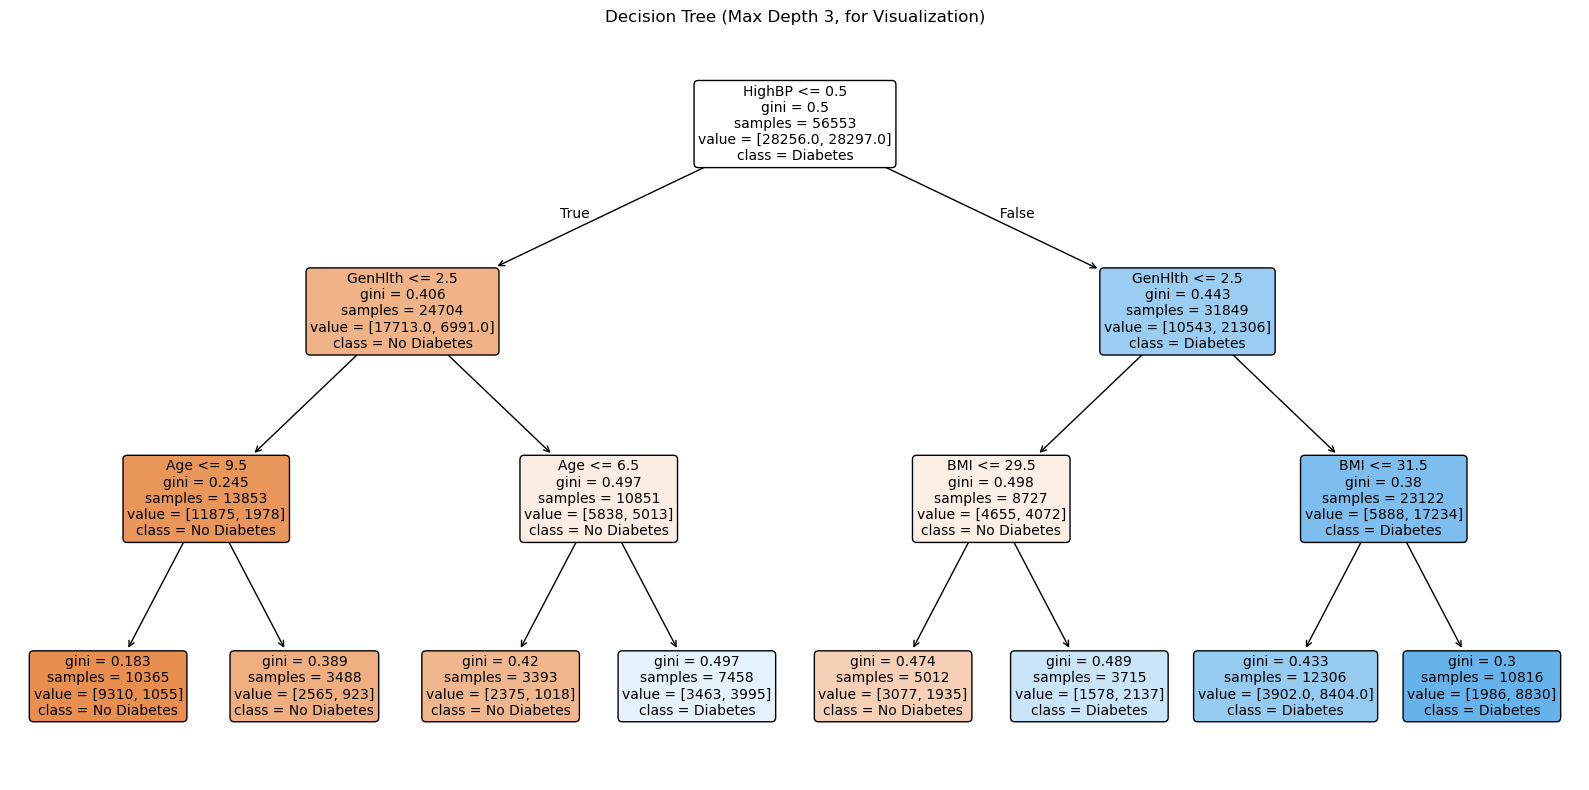

In [14]:
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(dt_viz, feature_names=features, class_names=['No Diabetes', 'Diabetes'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree (Max Depth 3, for Visualization)')
plt.tight_layout()
plt.savefig('week6_decision_tree_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## Random Forest Classifier

A random forest builds many decision trees, each trained on a bootstrapped sample of the data with a randomized subset of features considered at each split. Predictions are combined by majority vote across all trees. This randomization is intended to reduce the overfitting seen in the single unrestricted decision tree.

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f"Random Forest (100 trees, default depth)")
print(f"Accuracy: {acc_rf:.4f}")
print(f"AUC-ROC: {auc_rf:.4f}")

Random Forest (100 trees, default depth)
Accuracy: 0.7208
AUC-ROC: 0.7930


## Controlling Random Forest Depth

Default random forest trees had no depth limit, likely causing overfitting at the individual tree level. Max depth is tested to see if constraining tree depth improves forest performance, similar to the single tree experiment.

In [9]:
depths_rf = [3, 4, 5, 6, 8, 10]
results_rf = []

for depth in depths_rf:
    rf_d = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    rf_d.fit(X_train, y_train)
    y_pred_rfd = rf_d.predict(X_test)
    acc_rfd = accuracy_score(y_test, y_pred_rfd)
    auc_rfd = roc_auc_score(y_test, rf_d.predict_proba(X_test)[:, 1])
    results_rf.append({'Max Depth': depth, 'Accuracy': acc_rfd, 'AUC-ROC': auc_rfd})

results_rf_df = pd.DataFrame(results_rf)
print(results_rf_df)

   Max Depth  Accuracy   AUC-ROC
0          3  0.736332  0.808412
1          4  0.739303  0.813555
2          5  0.741920  0.817543
3          6  0.744749  0.820854
4          8  0.742980  0.822392
5         10  0.740151  0.818457


## Feature Importances

Random forests track how often each feature is used for splitting across all trees, providing a feature importance ranking. This is compared against the consistent top features identified through linear models, regularization, and feature selection in Weeks 1-3.

    Feature  Importance
0   GenHlth    0.322554
2    HighBP    0.294068
1       BMI    0.156635
3       Age    0.116782
4  HighChol    0.109961


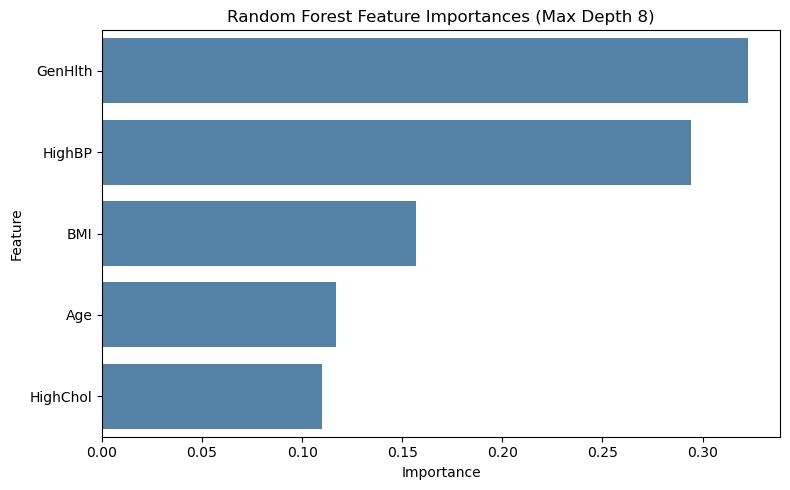

In [15]:
rf_best = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_best.fit(X_train, y_train)

importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

print(importances)

plt.figure(figsize=(8, 5))
sns.barplot(data=importances, x='Importance', y='Feature', color='steelblue')
plt.title('Random Forest Feature Importances (Max Depth 8)')
plt.tight_layout()
plt.savefig('week6_rf_importances.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Model | Accuracy | AUC-ROC |
|---|---|---|
| Decision Tree (unrestricted, depth 24) | 0.7203 | 0.7817 |
| Decision Tree (max depth 6) | 0.7361 | 0.8135 |
| Random Forest (unrestricted) | 0.7208 | 0.7930 |
| Random Forest (max depth 8) | 0.7430 | 0.8224 |

The unrestricted decision tree overfit significantly, reaching depth 24 and underperforming every other model tested this week. Limiting max depth substantially improved both the single tree and the random forest, with the random forest at max depth 8 achieving the best performance of any tree-based model, nearly matching Week 4's logistic regression (0.8232 AUC-ROC).

Feature importances from the random forest show GenHlth and HighBP as the dominant predictors (32% and 29% respectively), a slightly different ranking than the linear models' top features (GenHlth and BMI), reflecting the different ways tree-based splits versus linear coefficients capture predictive power.

Across six weeks of modeling (Weeks 1-6), no technique has decisively outperformed logistic regression. The relationship between these five health indicators and diabetes risk appears to be largely linear and additive, with added model complexity (polynomial terms, SVM kernels, deep trees, forests) failing to meaningfully improve on a properly regularized linear approach.

## Cost Complexity Pruning (ccp_alpha)

An alternative to manually testing max_depth values is cost complexity pruning, controlled by the ccp_alpha parameter. Rather than restricting depth directly, ccp_alpha prunes branches that add little predictive value based on a cost complexity measure, with higher values producing simpler trees. This is tested as a comparison to the manual max_depth search performed above.

Source: scikit-learn documentation, Post-pruning decision trees with cost complexity pruning (https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html)

In [11]:
ccp_alphas = [0.0, 0.001, 0.005, 0.01, 0.02]
results_ccp = []

for alpha in ccp_alphas:
    dt_ccp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    dt_ccp.fit(X_train, y_train)
    y_pred_ccp = dt_ccp.predict(X_test)
    acc_ccp = accuracy_score(y_test, y_pred_ccp)
    auc_ccp = roc_auc_score(y_test, dt_ccp.predict_proba(X_test)[:, 1])
    results_ccp.append({'ccp_alpha': alpha, 'Accuracy': acc_ccp, 'AUC-ROC': auc_ccp, 'Tree Depth': dt_ccp.get_depth()})

results_ccp_df = pd.DataFrame(results_ccp)
print(results_ccp_df)

   ccp_alpha  Accuracy   AUC-ROC  Tree Depth
0      0.000  0.720348  0.781727          24
1      0.001  0.727986  0.795490           5
2      0.005  0.699696  0.751035           2
3      0.010  0.699696  0.751035           2
4      0.020  0.686258  0.715764           2


Cost complexity pruning at ccp_alpha = 0.001 achieved 0.7955 AUC-ROC at depth 5, slightly below the manually tuned max_depth = 6 result (0.8135 AUC-ROC). For this dataset, direct max_depth tuning outperformed ccp_alpha pruning, though ccp_alpha required testing far fewer values to find a reasonable result.

## Permutation Importance

Impurity-based feature importance (used above) can be biased toward features with many unique values, since they offer more possible split points regardless of true predictive power. Permutation importance addresses this by measuring how much model performance drops when a feature's values are randomly shuffled, calculated on the test set rather than during training.

Source: scikit-learn documentation, Feature importances with a forest of trees (https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html)

    Feature  Importance
0   GenHlth    0.056539
1       BMI    0.033828
3       Age    0.030009
2    HighBP    0.019054
4  HighChol    0.009145


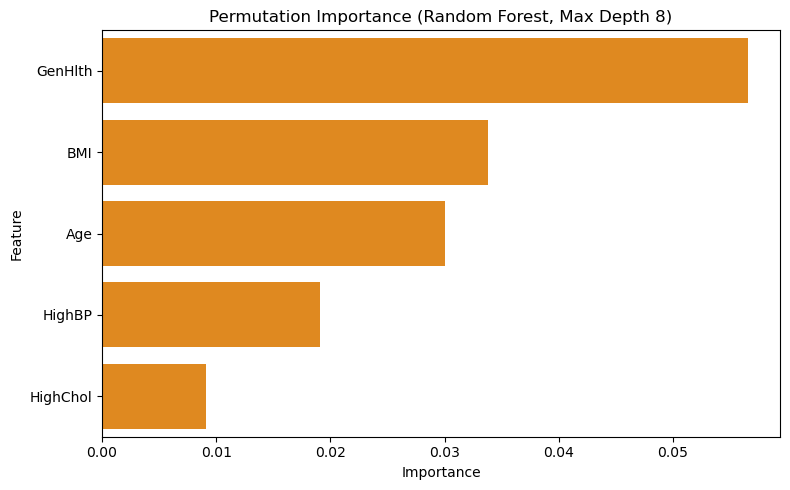

In [12]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rf_best, X_test, y_test, n_repeats=10, random_state=42)

perm_importances = pd.DataFrame({
    'Feature': features,
    'Importance': perm_result.importances_mean
}).sort_values('Importance', ascending=False)

print(perm_importances)

plt.figure(figsize=(8, 5))
sns.barplot(data=perm_importances, x='Importance', y='Feature', color='darkorange')
plt.title('Permutation Importance (Random Forest, Max Depth 8)')
plt.tight_layout()
plt.show()

Permutation importance shifted the ranking compared to impurity-based importance. GenHlth remained the top feature in both methods, but HighBP dropped from second to fourth place under permutation importance, while BMI and Age rose. This suggests HighBP's high impurity-based importance was partly inflated by being the first and most frequent split point rather than reflecting its true predictive contribution. This result aligns more closely with the linear models from Weeks 1-4, where BMI and GenHlth were consistently the top two features.

## Out-of-Bag (OOB) Score

Random forests can estimate validation performance internally using out-of-bag samples, the roughly one-third of training data each individual tree does not see due to bootstrap sampling. This provides a built-in performance estimate without needing a separate validation set, calculated using the held-out samples for each tree and averaged across the forest.

In [13]:
rf_oob = RandomForestClassifier(n_estimators=100, max_depth=8, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print(f"OOB Score: {rf_oob.oob_score_:.4f}")
print(f"Test Set Accuracy: {accuracy_score(y_test, rf_oob.predict(X_test)):.4f}")

OOB Score: 0.7448
Test Set Accuracy: 0.7430


The OOB score (0.7448) closely matches the test set accuracy (0.7430), differing by less than 0.2 percentage points. This confirms OOB score is a reliable internal estimate of model performance for this dataset, suggesting it could substitute for a separate validation set in future analysis if needed.